# Chapter 15 — Deployment: Edge, Embedded & Cloud

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch15_deployment.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch15_deployment.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch15_deployment.ipynb)

> **Motivating question.** A sleep scorer in a notebook helps nobody — how does it become a wristband, a service, or a cloud API?

## What this notebook demonstrates

- The edge → embedded → server → cloud spectrum
- What leaves the device: raw signal vs features vs decision
- Quantization and pruning: measured size/latency trade-offs
- MLOps, privacy, and regulatory pathways (discussed in the book text; not modelled in this notebook)

## What you'll do

You'll measure the actual size and latency trade-off from quantizing and pruning a model, and work through what data leaves the device at each point on the edge-to-cloud spectrum.

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | conceptual only — use Colab for the full version |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

CH = 15


def _measure_compression(n=2048, d=512, reps=40):
    """Measure real effects. Quantization: FP32 vs INT8 storage (exact 4×). Pruning:
    matmul latency of a full d×d layer vs a 4×-narrower (75%-pruned) one — a genuine
    CPU speed-up from fewer multiplies. INT8 matmul is *not* timed as a speed-up because
    numpy/BLAS has no fast INT8 kernel: that gain is hardware (edge-NPU) dependent."""
    import time
    rng = np.random.default_rng(0)
    W32 = rng.standard_normal((d, d)).astype(np.float32)
    W8 = np.round(W32 / (np.abs(W32).max() / 127.0)).astype(np.int8)   # symmetric INT8
    Wp = W32[:, : d // 4]                                              # 75% channel pruning
    x = rng.standard_normal((n, d)).astype(np.float32)

    def timeit(fn):
        fn()
        t0 = time.perf_counter()
        for _ in range(reps):
            fn()
        return (time.perf_counter() - t0) / reps * 1e3
    return dict(size_fp32=W32.nbytes / 1e6, size_int8=W8.nbytes / 1e6,
                lat_full=timeit(lambda: x @ W32), lat_pruned=timeit(lambda: x @ Wp))


def _measure_quantized_classifier(seed=0):
    """Quantize a *trained* classifier's weights and MEASURE the accuracy cost.

    Train a small MLP (one hidden layer), then post-training-quantize every weight
    matrix to INT8 and, for contrast, to a too-coarse INT2, and recompute held-out
    accuracy with a manual forward pass. The lesson is honest and measured, not
    asserted: INT8 is essentially lossless at an exact 4x storage cut, but pushing
    precision too low (INT2) is a *wrong* choice that wrecks accuracy — the §1.8
    'no single best, but choices can be wrong' worldview, in numbers."""
    from sklearn.datasets import make_classification
    from sklearn.neural_network import MLPClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score

    X, y = make_classification(n_samples=1600, n_features=40, n_informative=16,
                               n_classes=4, n_clusters_per_class=1, random_state=seed)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.4, random_state=seed)
    sc = StandardScaler().fit(Xtr)
    Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    net = MLPClassifier((64,), max_iter=800, alpha=1e-4, random_state=seed).fit(Xtr, ytr)
    Ws = [w.astype(np.float32) for w in net.coefs_]
    bs_ = [b.astype(np.float32) for b in net.intercepts_]

    def quant(W, bits):                                    # symmetric per-tensor PTQ,
        qmax = 2 ** (bits - 1) - 1                          # dequantized for the forward pass
        s = np.abs(W).max() / qmax
        return np.round(W / s) * s

    def quant_int8_bytes(weights):
        """The genuine byte-reduced INT8 array (not dequantized), so its size
        is a real measurement (via .nbytes) rather than an asserted /4."""
        qmax = 2 ** 7 - 1
        packed = [np.clip(np.round(W / (np.abs(W).max() / qmax)), -qmax - 1, qmax)
                  .astype(np.int8) for W in weights]
        return sum(p.nbytes for p in packed)

    def forward(weights):                                  # relu MLP, argmax head
        h = Xte
        for i, (W, b) in enumerate(zip(weights, bs_)):
            h = h @ W + b
            if i < len(weights) - 1:
                h = np.maximum(h, 0.0)
        return accuracy_score(yte, np.argmax(h, axis=1))

    size_fp32 = sum(W.nbytes for W in Ws) / 1e3            # kB
    return dict(acc_fp32=forward(Ws),
                acc_int8=forward([quant(W, 8) for W in Ws]),
                acc_int2=forward([quant(W, 2) for W in Ws]),
                clf_size_fp32=size_fp32,
                clf_size_int8=quant_int8_bytes(Ws) / 1e3)

## 15.1  deploy

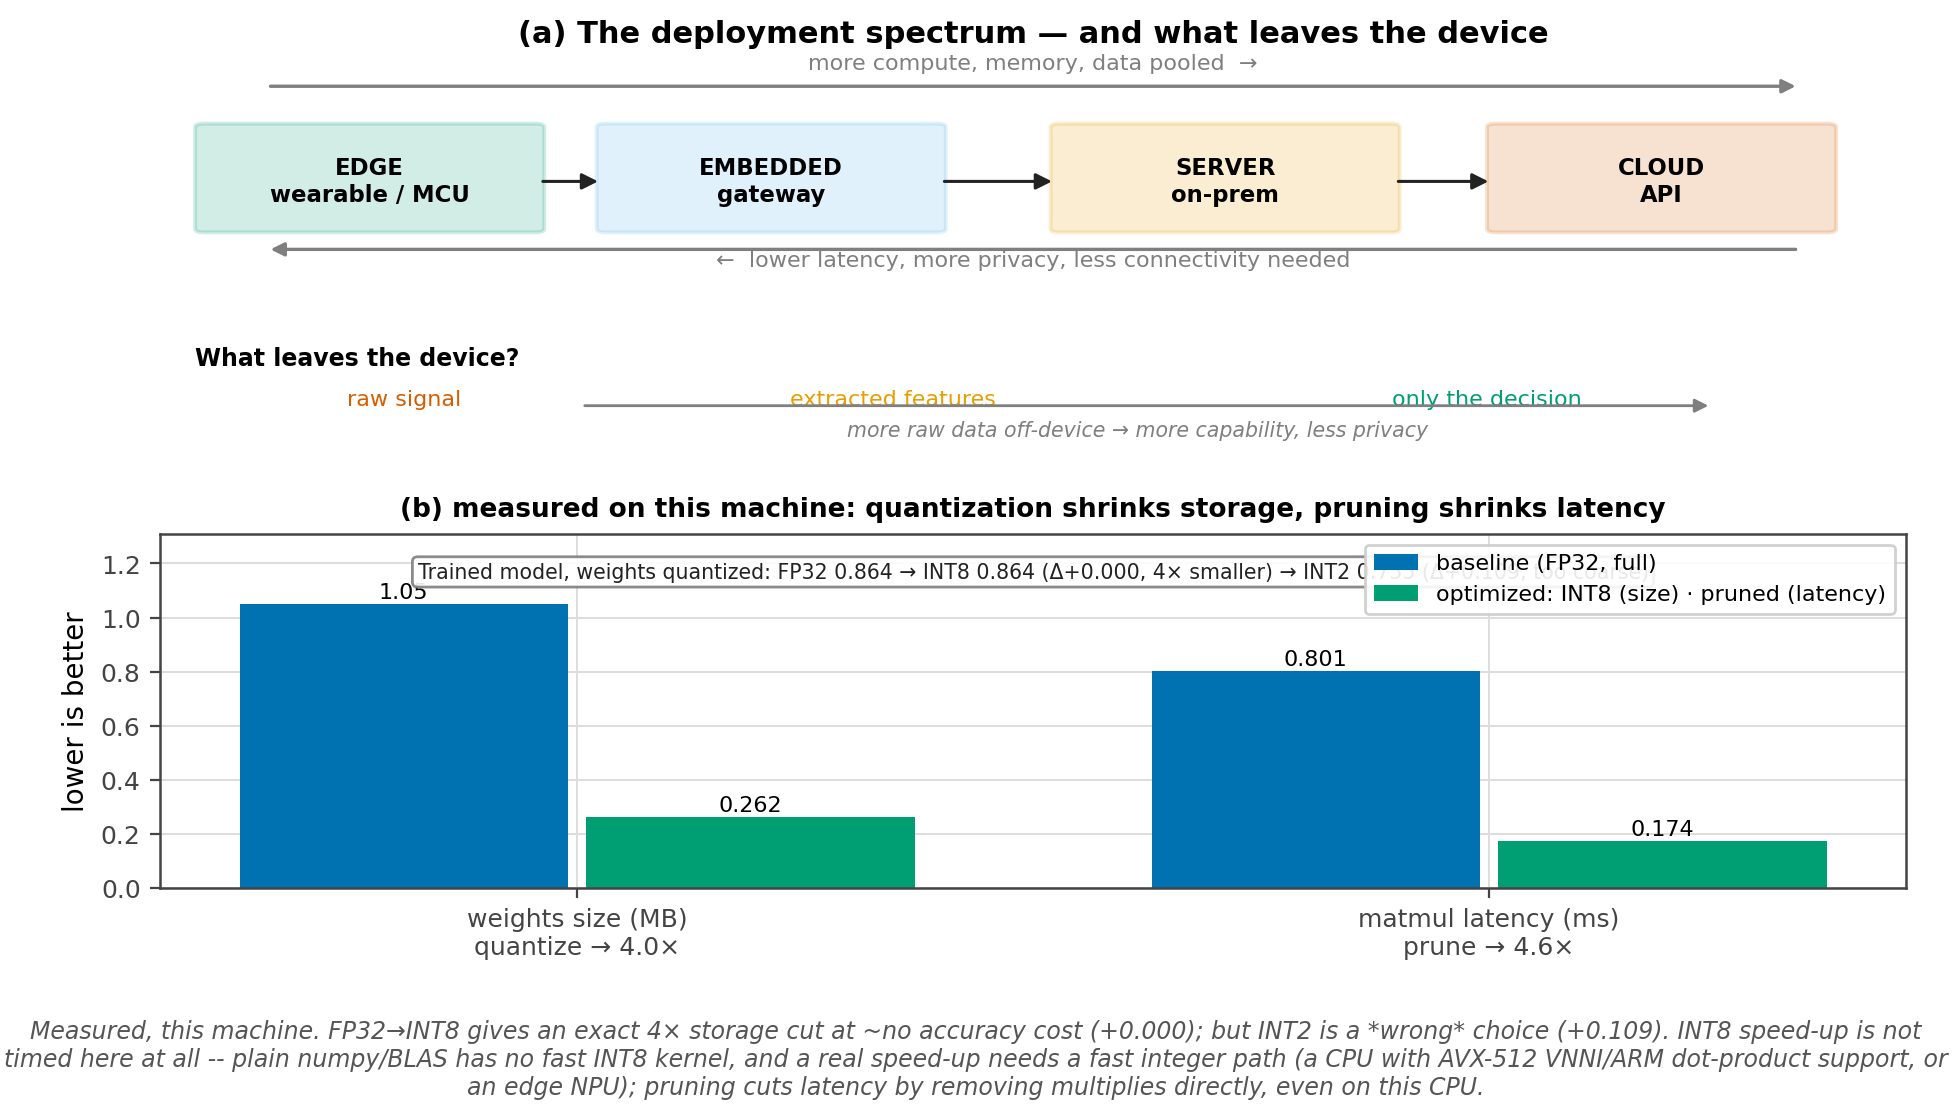

In [3]:
fig, axes = bs.newfig(w=9.6, h=5.0, nrows=2,
                      gridspec_kw={"height_ratios": [1.15, 1.0]})

# ================= (a) deployment spectrum =========================
axA = axes[0]
axA.set_xlim(0, 10); axA.set_ylim(0, 6); axA.axis("off")
axA.set_title("(a) The deployment spectrum — and what leaves the device",
              fontsize=11)

tiers = [
    ("EDGE\nwearable / MCU", 1.2, bs.C["green"]),
    ("EMBEDDED\ngateway", 3.5, bs.C["sky"]),
    ("SERVER\non-prem", 6.1, bs.C["orange"]),
    ("CLOUD\nAPI", 8.6, bs.C["red"]),
]
ymid = 4.2
for (label, xc, col) in tiers:
    box = FancyBboxPatch((xc - 0.95, ymid - 0.7), 1.9, 1.5,
                         boxstyle="round,pad=0.05", linewidth=1.4,
                         edgecolor=col, facecolor=col, alpha=0.18)
    axA.add_patch(box)
    axA.text(xc, ymid, label, ha="center", va="center", fontsize=8.2,
             fontweight="bold")
for x0, x1 in zip([t[1] for t in tiers[:-1]], [t[1] for t in tiers[1:]]):
    axA.add_patch(FancyArrowPatch((x0 + 0.96, ymid), (x1 - 0.96, ymid),
                  arrowstyle="-|>", mutation_scale=12,
                  color=bs.C["black"], lw=1.1))

# axis annotations: what grows as you move right / left
axA.annotate("", xy=(9.4, 5.6), xytext=(0.6, 5.6),
             arrowprops=dict(arrowstyle="-|>", color=bs.C["grey"], lw=1.2))
axA.text(5.0, 5.85, "more compute, memory, data pooled  →",
         ha="center", fontsize=8, color=bs.C["grey"])
axA.annotate("", xy=(0.6, 3.2), xytext=(9.4, 3.2),
             arrowprops=dict(arrowstyle="-|>", color=bs.C["grey"], lw=1.2))
axA.text(5.0, 2.95, "←  lower latency, more privacy, less connectivity needed",
         ha="center", fontsize=8, color=bs.C["grey"])

# the raw / feature / decision boundary: what crosses off the device
axA.text(0.2, 1.5, "What leaves the device?", fontsize=8.5, fontweight="bold")
axA.text(1.4, 0.9, "raw signal", fontsize=8, color=bs.C["red"],
         ha="center")
axA.text(4.2, 0.9, "extracted features", fontsize=8, color=bs.C["orange"],
         ha="center")
axA.text(7.6, 0.9, "only the decision", fontsize=8, color=bs.C["green"],
         ha="center")
axA.annotate("", xy=(8.9, 0.9), xytext=(2.4, 0.9),
             arrowprops=dict(arrowstyle="-|>", color=bs.C["grey"], lw=1.0))
axA.text(5.6, 0.45, "more raw data off-device → more capability, "
         "less privacy", fontsize=7.4, color=bs.C["grey"], ha="center",
         style="italic")

# ================= (b) quantization trade-off — MEASURED ============
# We measure a representative dense layer (the bulk of a small model's
# weights) rather than quoting numbers: FP32 vs INT8 storage is exact, and
# matmul latency is timed on THIS machine. Size gain is universal; the speed
# gain is hardware-dependent, which is exactly the point.
m = _measure_compression()
q = _measure_quantized_classifier()   # INT8 accuracy cost on a REAL trained model
axB = axes[1]
# two honest, MEASURED effects: quantization shrinks size; pruning shrinks latency
xp = np.arange(2)
base = [m["size_fp32"], m["lat_full"]]
opt = [m["size_int8"], m["lat_pruned"]]
b1 = axB.bar(xp - 0.19, base, width=0.36, color=bs.C["blue"], label="baseline (FP32, full)")
# one green series, but the two bars use DIFFERENT levers: INT8 shrinks size,
# pruning shrinks latency — name both so the coincidental 4x on each isn't read
# as one lever doing both.
b2 = axB.bar(xp + 0.19, opt, width=0.36, color=bs.C["green"],
             label="optimized: INT8 (size) · pruned (latency)")
for bars, vals in [(b1, base), (b2, opt)]:
    for bar, v in zip(bars, vals):
        axB.text(bar.get_x() + bar.get_width() / 2, v + 0.02 * max(base),
                 f"{v:.3g}", ha="center", fontsize=8)
axB.set_xticks(xp)
axB.set_xticklabels([f"weights size (MB)\nquantize → {m['size_fp32']/m['size_int8']:.1f}×",
                     f"matmul latency (ms)\nprune → {m['lat_full']/m['lat_pruned']:.1f}×"])
axB.set_title("(b) measured on this machine: quantization shrinks storage, "
              "pruning shrinks latency", fontsize=9.5)
axB.set_ylabel("lower is better")
axB.legend(loc="upper right", fontsize=8)
axB.set_ylim(0, 1.25 * max(base))
# Accuracy is measured on a REAL trained classifier (not the synthetic latency
# layer): INT8 is ~free, but too-coarse INT2 is a wrong choice — both numbers.
axB.text(0.5, 0.92,
         f"Trained model, weights quantized: FP32 {q['acc_fp32']:.3f} → "
         f"INT8 {q['acc_int8']:.3f} (Δ{q['acc_fp32']-q['acc_int8']:+.3f}, 4× smaller) → "
         f"INT2 {q['acc_int2']:.3f} (Δ{q['acc_fp32']-q['acc_int2']:+.3f}, too coarse)",
         transform=axB.transAxes, ha="center", va="top", fontsize=7.4,
         color=bs.C["black"],
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=bs.C["grey"], alpha=0.9))
bs.takeaway(fig, "Measured, this machine. FP32→INT8 gives an exact "
                 f"{m['size_fp32']/m['size_int8']:.0f}× storage cut at ~no accuracy cost "
                 f"({q['acc_fp32']-q['acc_int8']:+.3f}); but INT2 is a *wrong* choice "
                 f"({q['acc_fp32']-q['acc_int2']:+.3f}). INT8 speed-up is not timed here at all -- "
                 "plain numpy/BLAS has no fast INT8 kernel, and a real speed-up needs a fast integer "
                 "path (a CPU with AVX-512 VNNI/ARM dot-product support, or an edge NPU); "
                 "pruning cuts latency by removing multiplies directly, even on this CPU.", y=-0.03)
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above exactly. Change a parameter and watch them move — that loop between the page and the running code is where the intuition forms.

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> Export via ONNX (`exportONNXNetwork`); measure latency.

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Compare on-device-features vs stream-raw-to-cloud on latency and privacy.

<details><summary>💡 Hint &amp; what you should see</summary>

On-device features → low bandwidth + better privacy (raw never leaves) but fixed compute; stream-raw → flexible/heavy models but more data leaves and higher latency. **No free lunch.**

</details>

**2.** Quantize a *trained* classifier to INT8 (see the demo cell) and tabulate the change in model **size** and **accuracy** — confirm the 4x size drop costs little accuracy. For **latency**, note it is hardware-dependent: the notebook shows the CPU latency lever (pruning) separately, and a real INT8 speed-up needs an edge-NPU kernel.

<details><summary>💡 Hint &amp; what you should see</summary>

int8 quantization ≈ **4× smaller** than float32 with a small accuracy cost (size ∝ params × bytes/param). The *speed-up* is hardware-dependent — on a general-purpose CPU INT8 often gives no latency gain (no fast integer-matmul kernel); the latency win here comes from pruning, and a real INT8 speed-up needs an edge NPU.

</details>

In [4]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch15_figures.py`.*